# Analisis Komparatif Performa Model VGG19 dan DenseNet169 pada Klasifikasi Penyakit Daun Padi

## Abstrak
Penelitian ini bertujuan untuk mengevaluasi stabilitas dan akurasi dua arsitektur CNN, yaitu VGG19 dan DenseNet169. Sebanyak 70 eksperimen dilakukan dengan variasi *random seed* (43-77) untuk memastikan konsistensi performa model dalam mengklasifikasikan penyakit daun padi.

# 1. Persiapan Library
Import semua modul yang diperlukan untuk analisis data dan visualisasi hasil.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lokasi data hasil eksperimen
DATA_PATH = '../04-data/training_runs.csv'

## 2. Memuat dan Meninjau Data
Memuat hasil eksperimen dari CSV ke dalam DataFrame untuk melihat performa kedua model.

In [3]:
# Memuat data
df = pd.read_csv(DATA_PATH)

# Menampilkan 5 data teratas dan info ringkas
print("Data Eksperimen:")
display(df.head())
print("\nInformasi Data:")
print(df.info())

Data Eksperimen:


,seed,densenet169,vgg19
0,43,81.05,89.65
1,44,79.15,82.74
2,45,81.08,91.21
3,46,90.89,79.96
4,47,88.84,83.39



Informasi Data:
<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   seed         35 non-null     int64  
 1   densenet169  35 non-null     float64
 2   vgg19        35 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 972.0 bytes
None


## 3. Statistik Deskriptif
Melihat perbandingan rata-rata (mean) dan standar deviasi (std) untuk menilai performa dan konsistensi masing-masing model.

In [13]:
stats_summary = df[['vgg19', 'densenet169']].describe()
stats_summary

,vgg19,densenet169
count,35.000000,35.000000
mean,84.905429,84.500571
std,4.544795,4.215527
min,78.700000,78.160000
25%,80.545000,80.660000
50%,83.610000,85.030000
75%,89.660000,88.625000
max,91.350000,91.350000


## 4. Visualisasi Perbandingan Performa
Visualisasi ini membantu kita melihat sebaran nilai (distribusi) akurasi dari 35 run yang telah dilakukan.

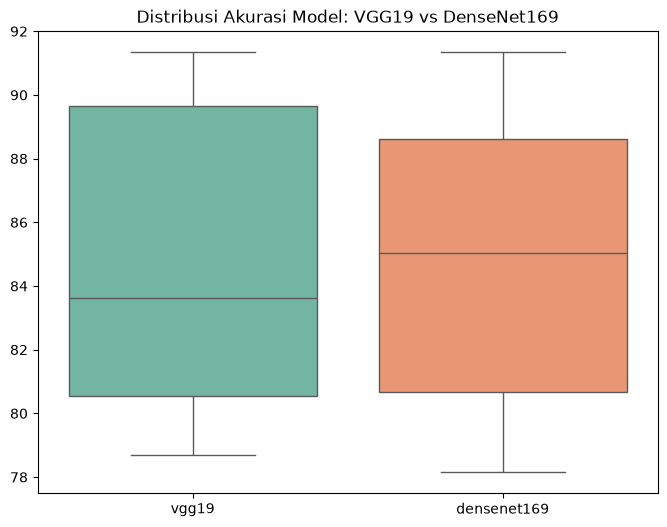

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df[['vgg19', 'densenet169']], palette="Set2")
plt.title('Distribusi Akurasi Model: VGG19 vs DenseNet169')
plt.show()

## 5. Uji Signifikansi Statistik
Menggunakan Independent T-Test untuk menentukan apakah perbedaan antara VGG19 dan DenseNet169 signifikan secara statistik.

In [15]:
# 1. Hitung rata-rata dan standar deviasi
mean_vgg = df['vgg19'].mean()
mean_dense = df['densenet169'].mean()

# 2. Uji T-Test
t_stat, p_value = stats.ttest_ind(df['vgg19'], df['densenet169'])

# 3. Cetak hasil lengkap
print(f"Rata-rata Akurasi VGG19   : {mean_vgg:.4f}")
print(f"Rata-rata Akurasi DenseNet169: {mean_dense:.4f}")
print("-" * 30)
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value    : {p_value:.4f}")

if p_value < 0.05:
    print("\nKesimpulan: Perbedaan signifikan (Model dengan rata-rata tertinggi lebih unggul).")
else:
    print("\nKesimpulan: Tidak ada perbedaan signifikan secara statistik.")

Rata-rata Akurasi VGG19   : 84.9054
Rata-rata Akurasi DenseNet169: 84.5006
------------------------------
T-Statistic: 0.3864
P-Value    : 0.7004

Kesimpulan: Tidak ada perbedaan signifikan secara statistik.


## Kesimpulan Analisis Komparatif Performa Model
Berdasarkan hasil eksperimen yang telah dilakukan terhadap model VGG19 dan DenseNet169 dengan variasi 35 random seed, dapat disimpulkan sebagai berikut:

1. Analisis Performa (Rata-rata):
Model VGG19 memiliki rata-rata akurasi yang sedikit lebih tinggi yaitu 84,9054%, dibandingkan dengan DenseNet169 yang memiliki rata-rata akurasi 84,5006%. Meskipun demikian, perbedaannya sangat tipis (hanya sekitar 0,4%).

2. Analisis Stabilitas:
Berdasarkan nilai standar deviasi (std), DenseNet169 memiliki nilai yang lebih rendah (4,2155) dibandingkan VGG19 (4,5447). Ini menunjukkan bahwa DenseNet169 cenderung sedikit lebih konsisten (stabil) dalam menghasilkan akurasi di berbagai seed dibandingkan VGG19 yang memiliki variansi sedikit lebih lebar.

3. Analisis Signifikansi Statistik (Uji Hipotesis):
Hasil uji Independent T-Test menunjukkan nilai T-Statistic sebesar 0,3864 dan P-Value sebesar 0,7004. Mengingat nilai P-Value (0,7004) jauh lebih besar dari 0,05, maka dapat disimpulkan bahwa tidak terdapat perbedaan performa yang signifikan secara statistik antara arsitektur VGG19 dan DenseNet169 dalam mengklasifikasikan penyakit daun padi.

## Implikasi Penelitian:
Karena tidak ditemukan perbedaan yang signifikan secara statistik, pemilihan antara kedua model ini dapat didasarkan pada faktor lain di luar akurasi, seperti efisiensi komputasi, waktu pelatihan, atau kebutuhan memori (karena DenseNet169 cenderung lebih efisien dalam penggunaan parameter dibandingkan VGG19).

In [ ]:
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definisikan path target
base_path = '../06-output'
figs_path = os.path.join(base_path, 'figures')
tabs_path = os.path.join(base_path, 'tables')
mods_path = os.path.join(base_path, 'models')

# 2. Buat direktori jika belum ada
for path in [figs_path, tabs_path, mods_path]:
    os.makedirs(path, exist_ok=True)

# 3. Simpan Tabel (Tables)
# Menyimpan summary statistik
df[['vgg19', 'densenet169']].describe().to_csv(os.path.join(tabs_path, 'summary_statistics.csv'))
# Menyimpan log lengkap
df.to_csv(os.path.join(tabs_path, 'full_runs_log.csv'), index=False)

# 4. Simpan Visualisasi (Figures)
plt.figure(figsize=(8, 6))
sns.boxplot(data=df[['vgg19', 'densenet169']], palette="Set2")
plt.title('Distribusi Akurasi Model: VGG19 vs DenseNet169')
plt.ylabel('Akurasi (%)')
plt.savefig(os.path.join(figs_path, 'fig_distribution_boxplot.png'))
plt.close()

# 5. Salin Notebook (asumsi nama file adalah 'klasifikasi_daun_padi.ipynb')
# Pastikan nama file di bawah sesuai dengan nama file .ipynb kamu
shutil.copyfile('klasifikasi_daun_padi.ipynb', os.path.join(base_path, 'klasifikasi_daun_padi_executed.ipynb'))

print(f"Berhasil! Semua output riset telah disimpan ke folder: {os.path.abspath(base_path)}")

In [5]:
import os
import shutil
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definisikan path target
base_path = '../06-output'
figs_path = os.path.join(base_path, 'figures')
tabs_path = os.path.join(base_path, 'tables')
mods_path = os.path.join(base_path, 'models')

# 2. Buat direktori jika belum ada
for path in [figs_path, tabs_path, mods_path]:
    os.makedirs(path, exist_ok=True)

# 3. Simpan Tabel (Tables)
# (Asumsi df sudah ada dari perhitungan sebelumnya)
df[['vgg19', 'densenet169']].describe().to_csv(os.path.join(tabs_path, 'summary_statistics.csv'))
df.to_csv(os.path.join(tabs_path, 'full_runs_log.csv'), index=False)

# 4. Simpan Visualisasi (Figures)
plt.figure(figsize=(8, 6))
sns.boxplot(data=df[['vgg19', 'densenet169']], palette="Set2")
plt.title('Distribusi Akurasi Model: VGG19 vs DenseNet169')
plt.ylabel('Akurasi (%)')
plt.savefig(os.path.join(figs_path, 'fig_distribution_boxplot.png'))
plt.close()

# 5. Simpan Konfigurasi Model ke folder models
model_configs = {
    "VGG19": {"input_shape": [224, 224, 3], "weights": "imagenet"},
    "DenseNet169": {"input_shape": [224, 224, 3], "weights": "imagenet"}
}
with open(os.path.join(mods_path, 'model_configs.json'), 'w') as f:
    json.dump(model_configs, f, indent=4)

# 6. Salin Notebook
# Ganti 'klasifikasi_daun_padi.ipynb' dengan nama file notebook kamu yang sebenarnya
try:
    shutil.copyfile('klasifikasi_daun_padi.ipynb', os.path.join(base_path, 'klasifikasi_daun_padi_executed.ipynb'))
except FileNotFoundError:
    print("Catatan: File notebook tidak ditemukan, salinan tidak dibuat.")

print(f"Berhasil! Semua output riset telah disimpan ke folder: {os.path.abspath(base_path)}")

Catatan: File notebook tidak ditemukan, salinan tidak dibuat.
Berhasil! Semua output riset telah disimpan ke folder: c:\Users\lenov\OneDrive\Documents\Coolyeah\4\Riset Teknologi Informasi\rti-20252_240202890\riset-directory\06-output
